In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400
2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000
2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400
2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800
2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200
...,...,...,...,...,...
2026-05-12,294.799988,295.269989,292.559998,292.559998,45748100
2026-05-13,298.869995,300.920013,293.500000,293.500000,52684300


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400
2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000
2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400
2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800
2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-05-12,294.799988,295.269989,292.559998,292.559998,45748100
2026-05-13,298.869995,300.920013,293.500000,293.500000,52684300
2026-05-14,298.209991,300.450012,295.380005,299.820007,35324900
2026-05-15,300.230011,303.200012,296.519989,297.899994,54862800
2026-05-18,297.839996,300.660004,294.910004,300.239990,34313641


## 2. Data Exploration and Visualization

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2513, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,123.175345,124.400401,121.830527,123.060941,9.674815e+07
std,76.294918,77.028017,75.491333,76.225650,5.481649e+07
min,20.952871,21.182798,20.829940,21.148654,1.791060e+07
25%,44.835629,45.191082,44.357002,44.708078,5.745070e+07
50%,128.927856,130.509542,127.382958,128.799390,8.492380e+07
75%,179.473923,180.945048,177.257367,179.241123,1.177263e+08
max,300.230011,303.200012,296.519989,300.239990,4.479400e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400
2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000
2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400
2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800
2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200


In [11]:
df = df.reset_index()

In [12]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400
1,2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000
2,2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400
3,2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800
4,2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200


Text(0, 0.5, 'Close price')

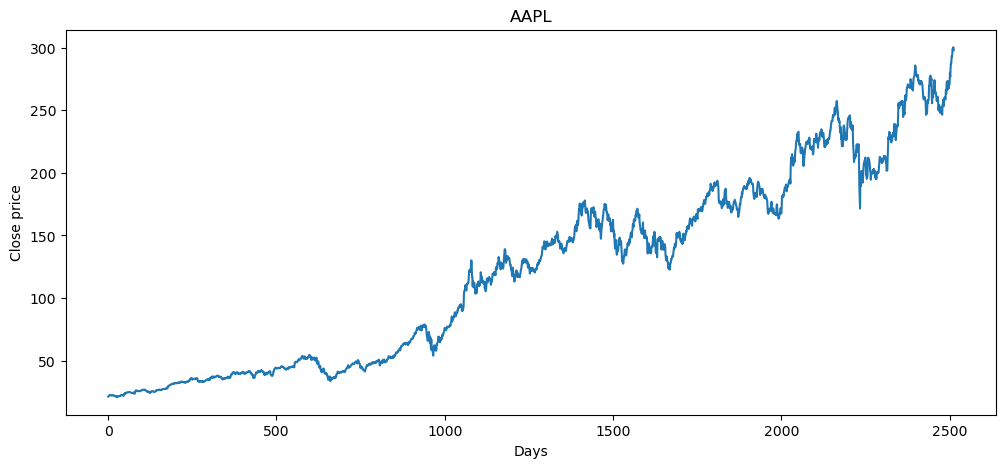

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

## 3. Feature Engineering

In [14]:
# 10, 20, 30, 40, 50, 60, 70 ,80, 90, 100

# MA of 5 days ==> null null null null null 30 40 50 60 70

In [15]:
temp_df = [10, 20, 30, 40, 50, 60, 70 ,80, 90, 100]
print(sum(temp_df[3:8])/5)

60.0


In [16]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70 ,80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [17]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days moving average

In [18]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400,NaN
1,2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000,NaN
2,2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400,NaN
3,2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800,NaN
4,2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200,NaN


In [19]:
df.tail()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
2508,2026-05-12,294.799988,295.269989,292.559998,292.559998,45748100,264.252976
2509,2026-05-13,298.869995,300.920013,293.500000,293.500000,52684300,264.528318
2510,2026-05-14,298.209991,300.450012,295.380005,299.820007,35324900,264.793565
2511,2026-05-15,300.230011,303.200012,296.519989,297.899994,54862800,265.064240
2512,2026-05-18,297.839996,300.660004,294.910004,300.239990,34313641,265.337965


In [20]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400,NaN
1,2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000,NaN
2,2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400,NaN
3,2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800,NaN
4,2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200,NaN
...,...,...,...,...,...,...,...
98,2016-10-07,26.106373,26.220814,25.980488,26.163594,97433600,NaN
99,2016-10-10,26.561861,26.722078,26.257446,26.326110,144944000,23.665750
100,2016-10-11,26.619078,27.166108,26.596188,26.939512,256164000,23.717495


Text(0, 0.5, 'Close price')

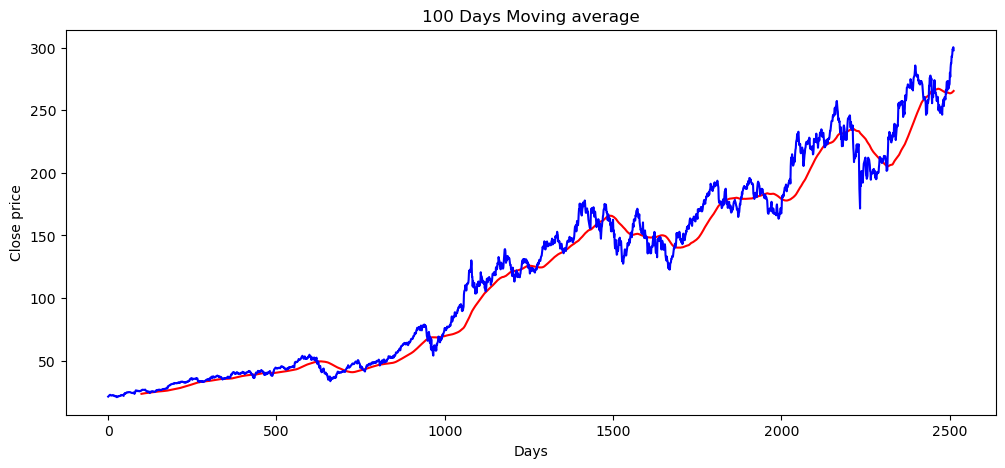

In [21]:
plt.figure(figsize=(12,5))

plt.plot(df['MA_100'], 'r')

plt.plot(df.Close, 'b')
plt.title('100 Days Moving average')
plt.xlabel('Days')
plt.ylabel('Close price')



### 200 Days Moving Average

In [22]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-05-19,21.444595,21.544762,21.301177,21.544762,121768400,NaN,NaN
1,2016-05-20,21.676796,21.724602,21.517440,21.544759,128104000,NaN,NaN
2,2016-05-23,21.952246,22.125260,21.779232,21.824763,152074400,NaN,NaN
3,2016-05-24,22.286894,22.330146,22.045584,22.132092,140560800,NaN,NaN
4,2016-05-25,22.678455,22.705772,22.334704,22.462187,152675200,NaN,NaN


Text(0, 0.5, 'Close price')

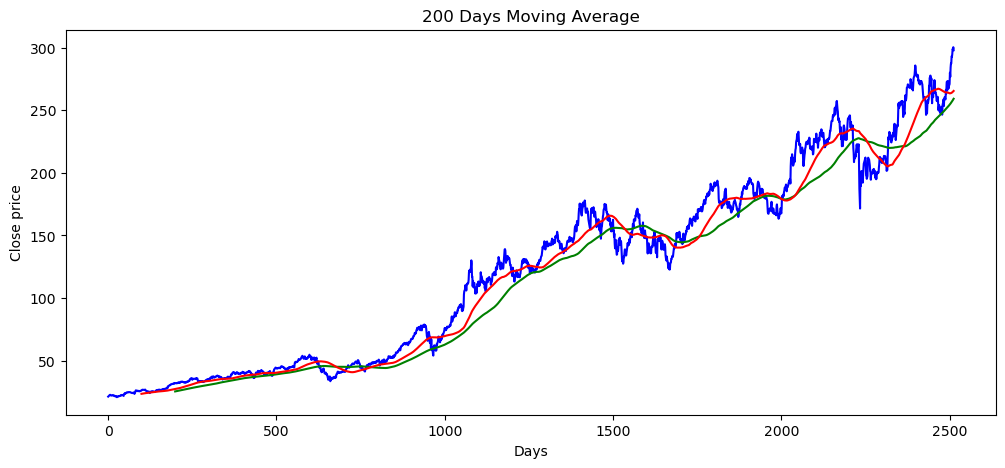

In [23]:
plt.figure(figsize=(12,5))
plt.plot(df.Close, 'b')

plt.plot(df['MA_200'], 'g')
plt.plot(df['MA_100'], 'r')

plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close price')

### Calculating % changed in each trading session

In [24]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,21.444595,NaN
1,21.676796,0.010828
2,21.952246,0.012707
3,22.286894,0.015244
4,22.678455,0.017569
...,...,...
2508,294.799988,0.007243
2509,298.869995,0.013806
2510,298.209991,-0.002208


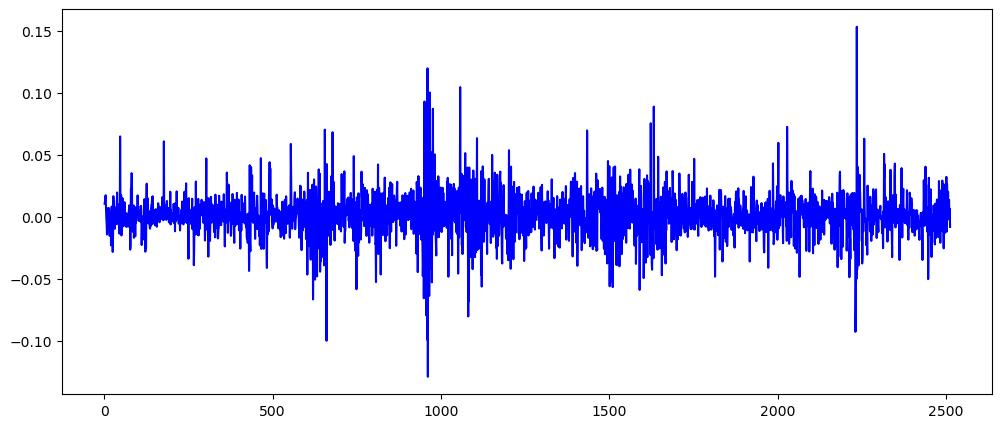

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'], 'b')

### 4. Data Preprocessing

In [26]:
df.shape

(2513, 9)

In [27]:
# Splitting data into Training and Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print('-----------------')
print(data_testing)

Ticker        AAPL
0        21.444595
1        21.676796
2        21.952246
3        22.286894
4        22.678455
...            ...
1754    169.161240
1755    170.924072
1756    171.111176
1757    170.184143
1758    169.691055

[1759 rows x 1 columns]
-----------------
Ticker        AAPL
1759    169.691055
1760    170.302505
1761    172.629868
1762    172.738342
1763    171.791611
...            ...
2508    294.799988
2509    298.869995
2510    298.209991
2511    300.230011
2512    297.839996

[754 rows x 1 columns]


In [28]:
data_training

Ticker,AAPL
0,21.444595
1,21.676796
2,21.952246
3,22.286894
4,22.678455
...,...
1754,169.161240
1755,170.924072
1756,171.111176
1757,170.184143


In [29]:
data_testing

Ticker,AAPL
1759,169.691055
1760,170.302505
1761,172.629868
1762,172.738342
1763,171.791611
...,...
2508,294.799988
2509,298.869995
2510,298.209991
2511,300.230011


In [30]:
# Scale down the data between 0 and 1

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [32]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00313226],
       [0.00461137],
       [0.00636597],
       ...,
       [0.9565023 ],
       [0.95059714],
       [0.94745619]], shape=(1759, 1))

In [33]:
type(data_training_array)

numpy.ndarray

In [34]:
data_training_array.shape

(1759, 1)

## 5. Sequence Creation

In [35]:
# 12, 13, 12, 15, 10, 14, 16, 19, 20     21

In [36]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [37]:
x_train

array([[[0.00313226],
        [0.00461137],
        [0.00636597],
        ...,
        [0.03257978],
        [0.0328276 ],
        [0.03572904]],

       [[0.00461137],
        [0.00636597],
        [0.00849767],
        ...,
        [0.0328276 ],
        [0.03572904],
        [0.0360935 ]],

       [[0.00636597],
        [0.00849767],
        [0.0109919 ],
        ...,
        [0.03572904],
        [0.0360935 ],
        [0.03760982]],

       ...,

       [[0.72151936],
        [0.7090549 ],
        [0.69565073],
        ...,
        [0.95493382],
        [0.94408129],
        [0.95531046]],

       [[0.7090549 ],
        [0.69565073],
        [0.69521227],
        ...,
        [0.94408129],
        [0.95531046],
        [0.9565023 ]],

       [[0.69565073],
        [0.69521227],
        [0.71494257],
        ...,
        [0.95531046],
        [0.9565023 ],
        [0.95059714]]], shape=(1659, 100, 1))

In [38]:
x_train.ndim

3

In [39]:
y_train.ndim

1

In [40]:
x_train.shape, y_train.shape

((1659, 100, 1), (1659,))

## 6. Model Building

In [41]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [42]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [47]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

## 7. Model Training

In [48]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0143
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 7.1740e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 6.9219e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 6.4831e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 6.7404e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 6.3059e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 6.5812e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 5.1255e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 6.4582e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 5.3091e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 4.8777e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 4.8875e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 4.3282e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 4.2464e-04
Epoch 15/50
52/52 ━

In [49]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [50]:
# Save the trained model
model.save('stock_prediction_model.keras')

## 8. Prepare Test Data

In [53]:
data_training

Ticker,AAPL
0,21.444595
1,21.676796
2,21.952246
3,22.286894
4,22.678455
...,...
1754,169.161240
1755,170.924072
1756,171.111176
1757,170.184143


In [52]:
data_testing

Ticker,AAPL
1759,169.691055
1760,170.302505
1761,172.629868
1762,172.738342
1763,171.791611
...,...
2508,294.799988
2509,298.869995
2510,298.209991
2511,300.230011


In [54]:
past_100_days = data_training.tail(100)

In [55]:
past_100_days

Ticker,AAPL
1659,130.092072
1660,133.189468
1661,130.023209
1662,129.659409
1663,127.859962
...,...
1754,169.161240
1755,170.924072
1756,171.111176
1757,170.184143


In [56]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [57]:
final_df

Ticker,AAPL
0,130.092072
1,133.189468
2,130.023209
3,129.659409
4,127.859962
...,...
849,294.799988
850,298.869995
851,298.209991
852,300.230011


In [60]:
input_data = scaler.fit_transform(final_df)
input_data

array([[4.03759676e-02],
       [5.78461242e-02],
       [3.99875621e-02],
       [3.79356313e-02],
       [2.77862682e-02],
       [5.65705311e-03],
       [2.54566960e-02],
       [2.72316307e-02],
       [2.77254212e-04],
       [7.43181571e-03],
       [0.00000000e+00],
       [2.55121640e-02],
       [2.84515836e-02],
       [3.16683866e-02],
       [4.69757624e-02],
       [4.65321041e-02],
       [5.40193018e-02],
       [6.05638438e-02],
       [5.65152351e-02],
       [5.68479574e-02],
       [7.12678444e-02],
       [8.92373426e-02],
       [9.71129458e-02],
       [9.33970595e-02],
       [1.05044060e-01],
       [1.15969847e-01],
       [9.97196432e-02],
       [1.06873946e-01],
       [1.13196788e-01],
       [1.43090412e-01],
       [1.63500075e-01],
       [1.48137446e-01],
       [1.64332053e-01],
       [1.49191124e-01],
       [1.43367796e-01],
       [1.45422997e-01],
       [1.61198043e-01],
       [1.57587498e-01],
       [1.69418848e-01],
       [1.60420457e-01],


In [61]:
input_data.shape

(854, 1)

In [62]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [63]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [64]:
x_test

array([[[0.04037597],
        [0.05784612],
        [0.03998756],
        ...,
        [0.27173482],
        [0.2665061 ],
        [0.26372495]],

       [[0.05784612],
        [0.03998756],
        [0.03793563],
        ...,
        [0.2665061 ],
        [0.26372495],
        [0.26372495]],

       [[0.03998756],
        [0.03793563],
        [0.02778627],
        ...,
        [0.26372495],
        [0.26372495],
        [0.2671737 ]],

       ...,

       [[0.83899977],
        [0.84733195],
        [0.83213137],
        ...,
        [0.95741585],
        [0.9693732 ],
        [0.99232914]],

       [[0.84733195],
        [0.83213137],
        [0.8399568 ],
        ...,
        [0.9693732 ],
        [0.99232914],
        [0.98860654]],

       [[0.83213137],
        [0.8399568 ],
        [0.84811994],
        ...,
        [0.99232914],
        [0.98860654],
        [1.        ]]], shape=(754, 100, 1))

In [65]:
y_test

array([0.26372495, 0.2671737 , 0.28030065, 0.28091248, 0.27557266,
       0.26088821, 0.26244553, 0.26884239, 0.2824142 , 0.29281603,
       0.29253788, 0.3083347 , 0.3131182 , 0.30549778, 0.30343982,
       0.29570829, 0.31100457, 0.31317389, 0.32891502, 0.32624516,
       0.32980509, 0.34126336, 0.33520069, 0.33570097, 0.32986069,
       0.34676989, 0.34498992, 0.33714745, 0.35266611, 0.35928501,
       0.36117652, 0.38553926, 0.37714022, 0.37085498, 0.37352451,
       0.36723919, 0.35572533, 0.35277722, 0.36217778, 0.3664604 ,
       0.36729496, 0.38565054, 0.38420424, 0.39182458, 0.38086695,
       0.3742477 , 0.37875305, 0.38359241, 0.38848737, 0.38136749,
       0.39588506, 0.39933363, 0.39466132, 0.37780755, 0.36996483,
       0.31890298, 0.30143738, 0.30672152, 0.29776625, 0.29654251,
       0.29687686, 0.30617837, 0.29498295, 0.29008162, 0.27576707,
       0.27849633, 0.28601563, 0.29375766, 0.31542419, 0.28902329,
       0.30144392, 0.31024436, 0.33213346, 0.35179514, 0.35302

In [66]:
x_test[0].shape

(100, 1)

## 9. Making Prediction

In [67]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [68]:
y_predicted

array([[0.27382085],
       [0.27205315],
       [0.2726194 ],
       [0.27899998],
       [0.2844637 ],
       [0.28533363],
       [0.2787073 ],
       [0.27378923],
       [0.27384186],
       [0.28064227],
       [0.29066703],
       [0.29726842],
       [0.3071145 ],
       [0.31552443],
       [0.31659544],
       [0.314607  ],
       [0.30936062],
       [0.31233534],
       [0.31680316],
       [0.32680076],
       [0.33259934],
       [0.33663788],
       [0.34366402],
       [0.3453975 ],
       [0.3454788 ],
       [0.34249315],
       [0.34792814],
       [0.3518924 ],
       [0.35031065],
       [0.35549435],
       [0.36278254],
       [0.36814395],
       [0.38217396],
       [0.38743606],
       [0.3854411 ],
       [0.38410708],
       [0.38044503],
       [0.37266475],
       [0.3664769 ],
       [0.36798823],
       [0.37248996],
       [0.37609324],
       [0.3866501 ],
       [0.39295632],
       [0.39907074],
       [0.39674586],
       [0.3905594 ],
       [0.388

In [69]:
y_test

array([0.26372495, 0.2671737 , 0.28030065, 0.28091248, 0.27557266,
       0.26088821, 0.26244553, 0.26884239, 0.2824142 , 0.29281603,
       0.29253788, 0.3083347 , 0.3131182 , 0.30549778, 0.30343982,
       0.29570829, 0.31100457, 0.31317389, 0.32891502, 0.32624516,
       0.32980509, 0.34126336, 0.33520069, 0.33570097, 0.32986069,
       0.34676989, 0.34498992, 0.33714745, 0.35266611, 0.35928501,
       0.36117652, 0.38553926, 0.37714022, 0.37085498, 0.37352451,
       0.36723919, 0.35572533, 0.35277722, 0.36217778, 0.3664604 ,
       0.36729496, 0.38565054, 0.38420424, 0.39182458, 0.38086695,
       0.3742477 , 0.37875305, 0.38359241, 0.38848737, 0.38136749,
       0.39588506, 0.39933363, 0.39466132, 0.37780755, 0.36996483,
       0.31890298, 0.30143738, 0.30672152, 0.29776625, 0.29654251,
       0.29687686, 0.30617837, 0.29498295, 0.29008162, 0.27576707,
       0.27849633, 0.28601563, 0.29375766, 0.31542419, 0.28902329,
       0.30144392, 0.31024436, 0.33213346, 0.35179514, 0.35302

In [70]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [71]:
y_predicted

array([171.48102, 171.16762, 171.268  , 172.39926, 173.36795, 173.52219,
       172.34737, 171.47542, 171.48474, 172.69043, 174.46779, 175.6382 ,
       177.38387, 178.87491, 179.0648 , 178.71225, 177.7821 , 178.3095 ,
       179.10162, 180.87418, 181.90224, 182.61826, 183.86395, 184.17131,
       184.18573, 183.65637, 184.61996, 185.32283, 185.04239, 185.96144,
       187.25362, 188.20418, 190.69164, 191.6246 , 191.27089, 191.03438,
       190.38512, 189.00569, 187.90862, 188.17657, 188.9747 , 189.61354,
       191.48524, 192.60332, 193.6874 , 193.27519, 192.17834, 191.8341 ,
       192.2055 , 192.97885, 192.87668, 193.9181 , 194.98215, 195.14148,
       193.58823, 191.78343, 186.51979, 181.75197, 179.66525, 178.34538,
       177.70718, 177.52995, 178.2332 , 177.94904, 177.16656, 175.47699,
       174.4687 , 174.55199, 175.4091 , 177.73085, 177.38083, 177.53954,
       178.38153, 180.70967, 183.9366 , 186.0568 , 187.7088 , 188.59357,
       185.76956, 181.14865, 178.57323, 178.06584, 

In [72]:
y_test

array([169.6910553 , 170.30250549, 172.62986755, 172.73834229,
       171.79161072, 169.18811035, 169.46421814, 170.59835815,
       173.0045929 , 174.84880066, 174.79948425, 177.60020447,
       178.44830322, 177.097229  , 176.73236084, 175.36158752,
       178.07356262, 178.45817566, 181.24902344, 180.77566528,
       181.40682983, 183.43833923, 182.3634491 , 182.45214844,
       181.41668701, 184.41462708, 184.0990448 , 182.70860291,
       185.46000671, 186.6335144 , 186.96887207, 191.28829956,
       189.79917908, 188.68482971, 189.15812683, 188.04376221,
       186.00239563, 185.47970581, 187.14639282, 187.90568542,
       188.0536499 , 191.30802917, 191.05160522, 192.40266418,
       190.45991516, 189.28634644, 190.08512878, 190.94313049,
       191.81098938, 190.54866028, 193.12257385, 193.73399353,
       192.90560913, 189.91749573, 188.52700806, 179.47392273,
       176.37733459, 177.31419373, 175.72645569, 175.50949097,
       175.56877136, 177.21789551, 175.23298645, 174.36

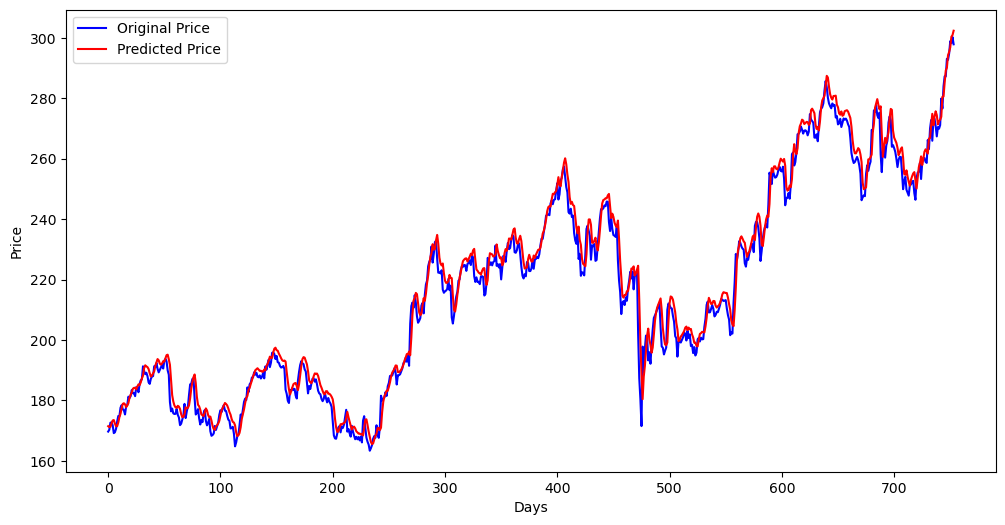

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(180.0, 240.0)

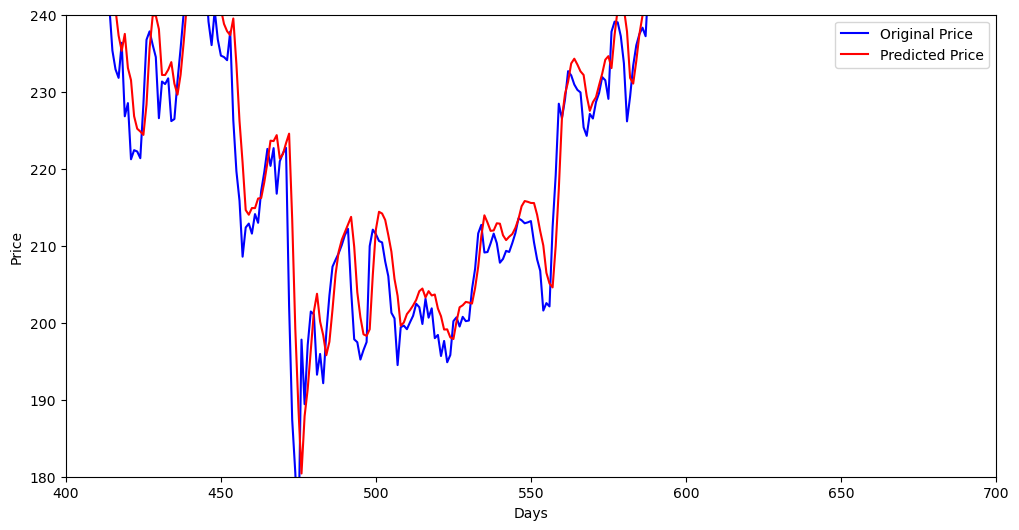

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(400, 700)
plt.ylim(180, 240)

## 10. Model Evaluation

In [84]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [85]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 19.809817936571577


In [86]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.450822164114354


In [87]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9828354097641826
